# Activity 3

**Name**: Andrea Elizabeth Grimaldo Hernández

**ID**: A01611890

**Link to Google Colab**: https://colab.research.google.com/drive/1Hdy0SCPCgmVTaTuko7L_UVJN5NRVQ_F3?usp=sharing



# Predicting the Price of Used Cars

The file "ToyotaCorolla.xlsx" contains data on used cars (Toyota Corolla) on sale during late summer of 2004 in the Netherlands. It has 1436 records containing details on 38 attributes, including Price, Age, Kilometers, HP, and other specifications. **The overall goal is to predict the price of a used Toyota Corolla using some selected attributes as predictors.**

## 0. Load the Python libraries.

In [ ]:
# Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

## 1. Read the data into Python.

In [ ]:
from typing_extensions import TypeVarTuple
toyota_data = pd.read_excel("ToyotaCorolla.xlsx")
toyota_data

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Tow_Bar,Validation
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,1
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,1
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,12,1998,20544,Petrol,86,1,...,1,1,0,1,1,1,0,0,0,0
1432,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,9,1998,19000,Petrol,86,0,...,0,1,0,0,1,1,0,0,0,0
1433,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,10,1998,17016,Petrol,86,0,...,0,1,0,0,0,1,0,0,0,0
1434,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,11,1998,16916,Petrol,86,1,...,0,0,0,0,0,1,0,0,0,0


## 2. Create subsets of the dataset.

2.A First, create two Python objects. One is `toyota_Y` and contains the variable `Price` in the "ToyotaCorolla.xlsx" file. The other is `toyota_X` and contains the variables `Age_08_04`, `KM`, `HP`, `CC`, `Quarterly_Tax`, and `Weight` in the datase. In this activity, we will treat all variables as numeric.

In [ ]:
#Respuesta
toyota_Y = toyota_data.filter(['Price'])

#Predictores
toyota_X = toyota_data.filter(['Age_08_04', 'KM', 'HP','CC','Quarterly_Tax','Weight'])


You will work with the `toyota_Y` and `toyota_X` for the rest of the activity. The **goal of the activity** is to train a linear regression model that predicts the price of toyota cars (in `toyota_Y`) based on the variables in `toyota_X`.

## 3. Data preprocessing: Identify and remove non-informative predictors.

### 3.A Identify predictors with a high absolute correlation. Use a threshold of 0.60.


In [ ]:
toyota_X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age_08_04      1436 non-null   int64
 1   KM             1436 non-null   int64
 2   HP             1436 non-null   int64
 3   CC             1436 non-null   int64
 4   Quarterly_Tax  1436 non-null   int64
 5   Weight         1436 non-null   int64
dtypes: int64(6)
memory usage: 67.4 KB


In [ ]:
# Correlation matrix
correlation_matrix = toyota_X.corr()
print(correlation_matrix)

               Age_08_04        KM        HP        CC  Quarterly_Tax  \
Age_08_04       1.000000  0.505672 -0.156622 -0.098084      -0.198431   
KM              0.505672  1.000000 -0.333538  0.102683       0.278165   
HP             -0.156622 -0.333538  1.000000  0.035856      -0.298432   
CC             -0.098084  0.102683  0.035856  1.000000       0.306996   
Quarterly_Tax  -0.198431  0.278165 -0.298432  0.306996       1.000000   
Weight         -0.470253 -0.028598  0.089614  0.335637       0.626134   

                 Weight  
Age_08_04     -0.470253  
KM            -0.028598  
HP             0.089614  
CC             0.335637  
Quarterly_Tax  0.626134  
Weight         1.000000  


Text(0.5, 1.0, 'Heatmap on correlations')

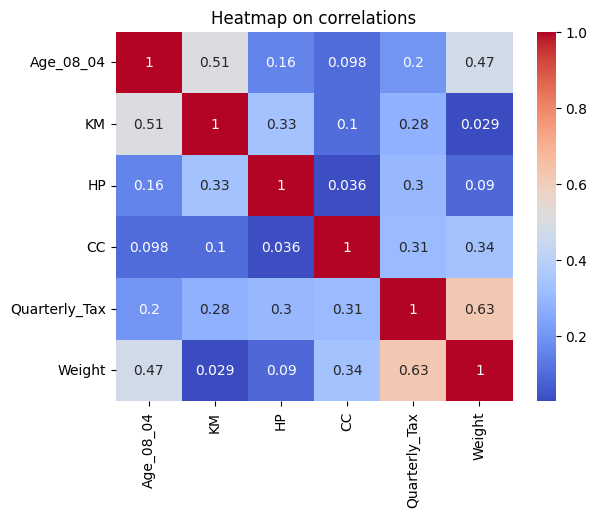

In [ ]:
# Plot the correlation matrix
sns.heatmap(correlation_matrix.abs(), cmap = 'coolwarm', annot = True)
plt.title("Heatmap on correlations") # Set plot title.

**Show the predictors that are highly correlated (if any)**:

In [ ]:
threshold = 0.60
high_correlation = correlation_matrix[(correlation_matrix.abs() > threshold) & (correlation_matrix != 1)]

high_corr_pairs = high_correlation.stack().reset_index()
high_corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']
high_corr_pairs

,Variable 1,Variable 2,Correlation
0,Quarterly_Tax,Weight,0.626134
1,Weight,Quarterly_Tax,0.626134


Considerando un threshold de 0.60, es posible identificar que las Variables "Quarterly Tax" y "Weight" están altamente correlacionadas, pues su correlación alcanzó un valor de 0.626 respectivamente.

Frente a este caso, es necesario despreciar a una de estas para que no afecte el análisis. En este caso particular, se tomó la decisión de eliminar el predictor ""Quarterly Tax".



### 3.B If there are predictors that have a high absolute correlation, remove them so that the remaining predictors have a low absolute correlation between them. Otherwise, proceed to Part 4.

In [ ]:
P_toyota = toyota_X.drop(columns=['Quarterly_Tax'])
P_toyota


,Age_08_04,KM,HP,CC,Weight
0,23,46986,90,2000,1165
1,23,72937,90,2000,1165
2,24,41711,90,2000,1165
3,26,48000,90,2000,1165
4,30,38500,90,2000,1170
...,...,...,...,...,...
1431,69,20544,86,1300,1025
1432,72,19000,86,1300,1015
1433,71,17016,86,1300,1015
1434,70,16916,86,1300,1015


## 4. Model training and interpretation

### 4.A Fit a multiple linear regression model.

The model predicts the Price in Euros of a Toyota car based on the predictors identified in Part 3. That is, the predictors that are not highly correlated.

In [ ]:
# Chose the predictor.
X_full = P_toyota

# Set the response.
Y_full = toyota_data.filter(['Price'])


### 4.B Calculate and show the estimates of the coefficients ($\beta_j$'s) of the model.

In [ ]:
# 1. Create the linear regression model
LRmodel = LinearRegression()

# 2. Fit the model.
LRmodel.fit(X_full, Y_full) #ajustar el modelo con los datos de entrenamiento

LinearRegression()

In [ ]:
print("Coefficients:", LRmodel.coef_)

Coefficients: [[-1.22416591e+02 -1.95200566e-02  3.03340464e+01 -8.89072875e-02
   1.87732273e+01]]


In [ ]:
print("Intercept:", LRmodel.intercept_)

Intercept: [-4154.85529669]


### 4.D Conduct t-tests to test $H_0:\beta_j = 0$ versus $H_1:\beta_j \neq 0$ for all predictors. Identify the significant coefficients in the model. That is, the ones for which you reject $H_0$. Use an $\alpha = 0.05$. *Hint*: For this problem, you may need to fit the model in 4.A again using functions from the **statsmodels** package.

In [ ]:
auto_X_train_with_intercept = sm.add_constant(X_full)

In [ ]:
# Create linear regression object in statsmodel
regr = sm.OLS(Y_full, auto_X_train_with_intercept)

# Train the model using the training sets
linear_model = regr.fit()

In [ ]:
model_summary = linear_model.summary()

print(model_summary)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     1785.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:35:31   Log-Likelihood:                -12385.
No. Observations:                1436   AIC:                         2.478e+04
Df Residuals:                    1430   BIC:                         2.481e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4154.8553    946.732     -4.389      0.0

### 4.E Based on Question 4.D, interpret the coefficients of the predictors that are significant. That is, predictors for which you rejected the $H_0: \beta_j = 0$.



**Show your interpretation here:**

El análisis del modelo demuestra que 4 de las 5 variables son estadísitcamente valiosas para el modelo, siendo estas "Age_08_04", "KM", "HP" y "Weight". La variable "CC" no es considerada estadísticamente significativa ya que no cumple con la regla de (p > 0.05), puesto que su p-value es de 0.323, lo que sugiere que la cilindrada no explica de manera clara el precio en este modelo.

Ahora bien, se hará una explicación de la relevancia de cada una de las variables significativas dentro del modelo:



*   Age: Cada mes adicional de antigüedad reduce el precio en promedio 122.42 unidades monetarias. Es la variable con mayor impacto negativo y altamente significativa

* KM: Por cada kilómetro adicional recorrido, el precio disminuye en promedio 0.0195 unidades.

* HP: Cada caballo de fuerza adicional aumenta el precio en promedio 30.33 unidades.

* Weight: Cada kilogramo adicional de peso incrementa el precio en promedio 18.77 unidades.






## 5. Model evaluation.

### 5.A Compute a K-fold cross validation estimate of the root mean squared error. Interpret the estimate.

In [ ]:
LRmodel_cv = LinearRegression()
neg_cv_RMSEs = cross_val_score(LRmodel_cv, X_full, Y_full, cv = 5,
                        scoring = "neg_root_mean_squared_error")
cv_RMSEs = -neg_cv_RMSEs
RMSE_cv = cv_RMSEs.mean()
print(round(RMSE_cv, 3))

1698.339


**Interpretation**

El resultado muestra un RMSE promedio de 1698.339, lo que significa que, en promedio, el modelo de regresión lineal comete un error de aproximadamente +-1698 unidades monetarias al predecir el precio de los autos.
